In [1]:
from q import edges, edges_supplement
import pandas as pd

In [3]:
disease_name = 'adult T-cell leukemia/lymphoma'

origin = edges.query(f"y_name == '{disease_name}' or x_name == '{disease_name}'")
print(origin.shape)

(38, 12)


In [4]:
supplement = pd.concat([
    edges,
    edges_supplement
], ignore_index=True).query(f"y_name == '{disease_name}' or x_name == '{disease_name}'")

print(supplement.shape)

(139, 13)


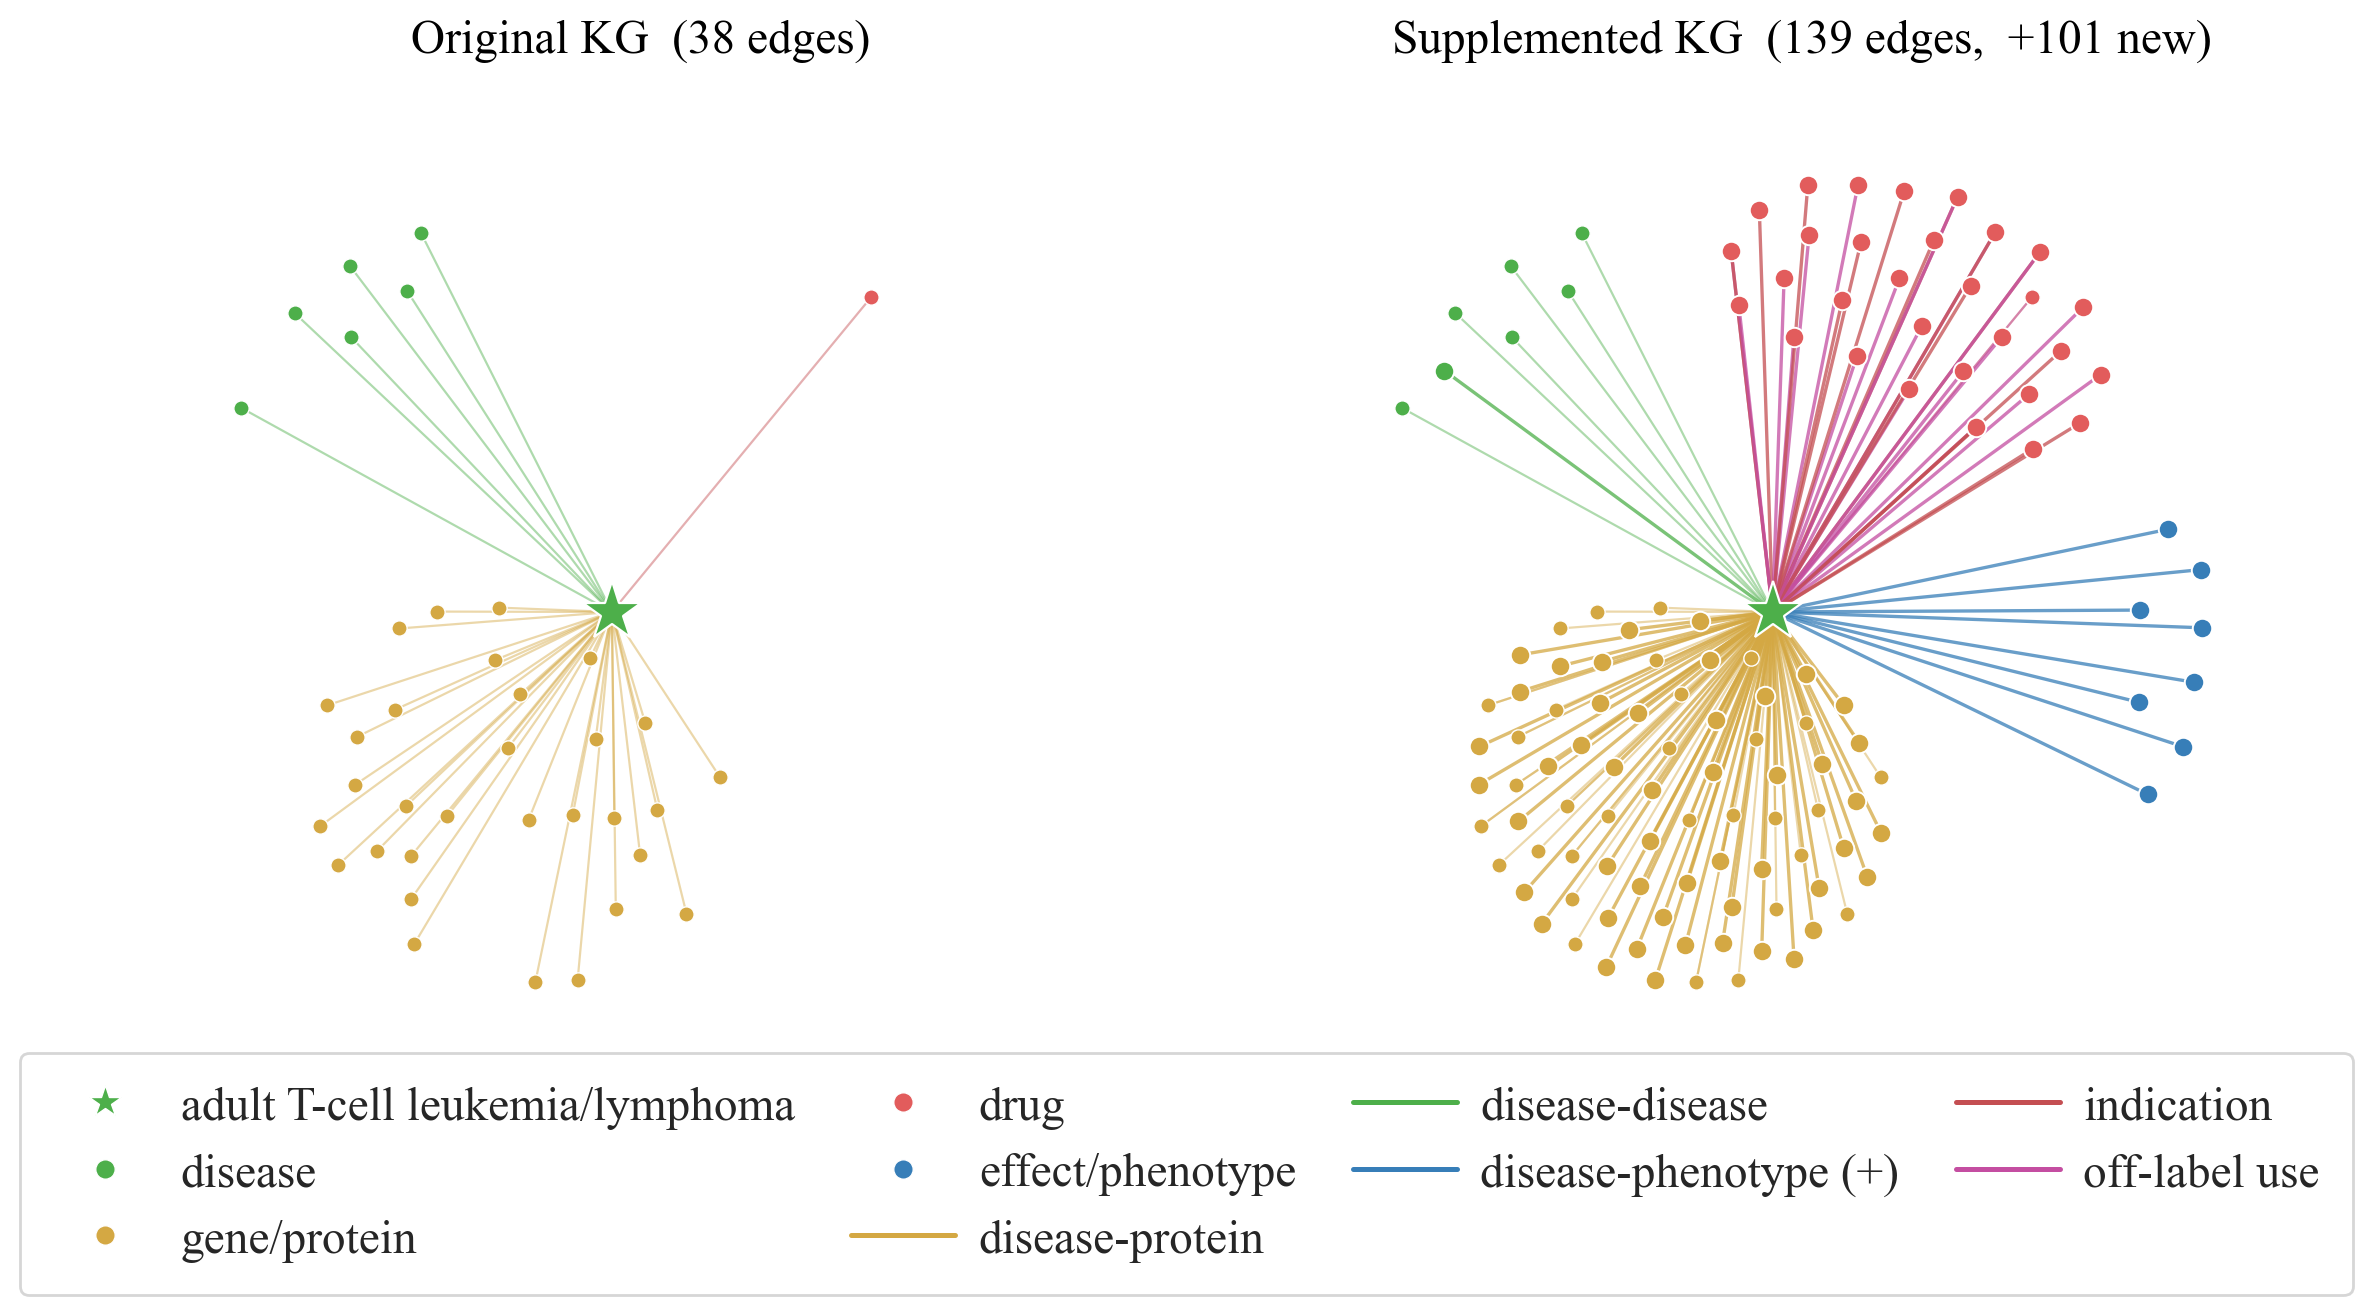

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from matplotlib.lines import Line2D
from collections import defaultdict

plt.rcParams['figure.dpi'] = 200
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 20
plt.rcParams['mathtext.fontset'] = 'stix'

center_node = disease_name

type_colors = {
    'gene/protein': '#D4A843',
    'disease': '#4DAF4A',
    'drug': '#E25C5C',
    'effect/phenotype': '#377EB8',
}

relation_colors = {
    'disease_protein': '#D4A843',
    'disease_disease': '#4DAF4A',
    'indication': '#C44E52',
    'off-label use': '#c44ea1',
    'disease_phenotype_positive': '#377EB8',
    'disease_phenotype_negative': '#7EB4D8',
}

def parse_edges(df, center_name):
    result = []
    for _, row in df.iterrows():
        if row['x_name'] == center_name:
            nb, nb_type = row['y_name'], row['y_type']
        else:
            nb, nb_type = row['x_name'], row['x_type']
        result.append({'name': nb, 'type': nb_type, 'relation': row['relation']})
    return result

origin_edge_list = parse_edges(origin, disease_name)
supplement_edge_list = parse_edges(supplement, disease_name)
origin_node_set = {e['name'] for e in origin_edge_list}

# --- 只对补充后的图做一次力导向布局，左图复用其中对应节点的位置 ---
G_supp = nx.Graph()
G_supp.add_node(center_node)
all_supp_nodes = {}
for e in supplement_edge_list:
    all_supp_nodes[e['name']] = e['type']
    G_supp.add_node(e['name'], node_type=e['type'])
    G_supp.add_edge(center_node, e['name'])

by_type_supp = defaultdict(list)
for name, tp in all_supp_nodes.items():
    if name not in by_type_supp[tp]:
        by_type_supp[tp].append(name)
for tp, names in by_type_supp.items():
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            G_supp.add_edge(names[i], names[j], weight=0.05)

supp_pos = nx.spring_layout(G_supp, k=1.8 / np.sqrt(len(G_supp)),
                            iterations=200, seed=42, weight='weight')

scx, scy = supp_pos[center_node]
for n in supp_pos:
    supp_pos[n] = (supp_pos[n][0] - scx, supp_pos[n][1] - scy)

max_r_supp = max(np.sqrt(x**2 + y**2) for n, (x, y) in supp_pos.items() if n != center_node)
if max_r_supp > 0:
    sc2 = 1.3 / max_r_supp
    for n in supp_pos:
        if n != center_node:
            supp_pos[n] = (supp_pos[n][0] * sc2, supp_pos[n][1] * sc2)

base_pos = {n: supp_pos[n] for n in supp_pos if n == center_node or n in origin_node_set}

# --- 绘图函数 ---
def draw_graph(ax, edge_list, pos, title, highlight_new=False):
    ax.set_aspect('equal')
    ax.axis('off')

    for e in edge_list:
        nb = e['name']
        if nb not in pos:
            continue
        x0, y0 = pos[center_node]
        x1, y1 = pos[nb]
        ec = relation_colors.get(e['relation'], '#aaaaaa')
        is_new = highlight_new and nb not in origin_node_set
        lw = 1.2 if is_new else 0.8
        alpha = 0.75 if is_new else 0.45
        ax.plot([x0, x1], [y0, y1], color=ec, linewidth=lw, alpha=alpha,
                zorder=1, solid_capstyle='round')

    drawn = set()
    for e in edge_list:
        nb = e['name']
        if nb in drawn or nb not in pos:
            continue
        drawn.add(nb)
        x, y = pos[nb]
        nc = type_colors.get(e['type'], '#888888')
        is_new = highlight_new and nb not in origin_node_set
        ms = 7 if is_new else 5.5
        ew = 0.7 if is_new else 0.5
        ax.plot(x, y, 'o', markersize=ms, color=nc,
                markeredgecolor='white', markeredgewidth=ew, zorder=5)

    ax.plot(0, 0, marker='*', markersize=22, color=type_colors['disease'],
            markeredgecolor='white', markeredgewidth=0.8, zorder=10)

    ax.set_title(title, fontsize=17, color='#000', pad=10)


# --- 统一坐标范围 ---
all_positions = list(base_pos.values()) + list(supp_pos.values())
all_xs = [p[0] for p in all_positions]
all_ys = [p[1] for p in all_positions]
margin = 0.3
global_xlim = (min(all_xs) - margin, max(all_xs) + margin)
global_ylim = (min(all_ys) - margin, max(all_ys) + margin)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), facecolor='white')

n_new = len(supplement) - len(origin)

draw_graph(ax1, origin_edge_list, base_pos,
           f'Original KG  ({len(origin)} edges)')
draw_graph(ax2, supplement_edge_list, supp_pos,
           f'Supplemented KG  ({len(supplement)} edges,  +{n_new} new)',
           highlight_new=True)

for ax in (ax1, ax2):
    ax.set_xlim(global_xlim)
    ax.set_ylim(global_ylim)

node_handles = [
    Line2D([0], [0], marker='*', color='white', markerfacecolor=type_colors['disease'],
           markersize=12, markeredgecolor='white', markeredgewidth=0.5,
           label='adult T-cell leukemia/lymphoma'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor=type_colors['disease'],
           markersize=7, markeredgecolor='white', markeredgewidth=0.5, label='disease'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor=type_colors['gene/protein'],
           markersize=7, markeredgecolor='white', markeredgewidth=0.5, label='gene/protein'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor=type_colors['drug'],
           markersize=7, markeredgecolor='white', markeredgewidth=0.5, label='drug'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor=type_colors['effect/phenotype'],
           markersize=7, markeredgecolor='white', markeredgewidth=0.5, label='effect/phenotype'),
]

edge_handles = [
    Line2D([0], [0], color=relation_colors['disease_protein'], linewidth=1.8, label='disease-protein'),
    Line2D([0], [0], color=relation_colors['disease_disease'], linewidth=1.8, label='disease-disease'),
    Line2D([0], [0], color=relation_colors['disease_phenotype_positive'], linewidth=1.8, label='disease-phenotype (+)'),
    Line2D([0], [0], color=relation_colors['indication'], linewidth=1.8, label='indication'),
    # Line2D([0], [0], color=relation_colors['contraindication'], linewidth=1.8, label='contraindication'),
    Line2D([0], [0], color=relation_colors['off-label use'], linewidth=1.8, label='off-label use'),
]

new_handle = [
    # Line2D([0], [0], marker='o', color='white', markerfacecolor='#999999',
    #        markersize=8, markeredgecolor='white', markeredgewidth=0.8,
    #        label='new (supplemented)'),
]

all_handles = node_handles + edge_handles + new_handle

fig.legend(handles=all_handles, loc='lower center', ncol=4, frameon=True,
           edgecolor='#CCCCCC', facecolor='white', fontsize=17,
           handlelength=2.2, handletextpad=0.5, columnspacing=1.2,
           bbox_to_anchor=(0.5, 0.0), borderpad=0.7)

plt.subplots_adjust(bottom=0.13, wspace=0.15, top=0.92)
# plt.savefig('supplement_comparison.pdf', bbox_inches='tight', facecolor='white', dpi=600)
plt.savefig('supplement_comparison.tif', bbox_inches='tight', facecolor='white', dpi=300, pil_kwargs={'compression': 'tiff_lzw'})
# plt.savefig('supplement_comparison.eps', bbox_inches='tight', facecolor='white', dpi=600)
plt.show()